# **Phase Resolved Analysis**

Powerful tool to see the evolution of different spectral parameters over a cycle of quasi-periodic variability (e.g. heartbeat variability and QPOs).
Possible takeaways: knowledge of correlations or anti-correlations between parameters, time lags, flux dependencies, ...

Example from Shui+2024 ("A Phase-resolved View of “Heartbeat”-like variability in IGR J17091–3624 During the 2022 Outburst"):

<img src="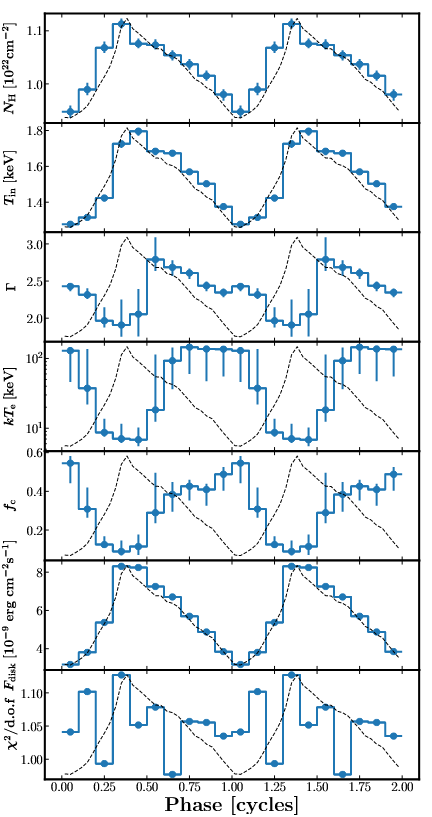
" alt="My plot" width="800"/>


## Principle of this approach

Comparing the correlation value between two segments for different relative time shifts. In detail:

   - Define a small segment and a larger segment of the observation
   - Compare the two segments (small segment to the first len(small segment) long part of the large segment) and take the correlation value
   - Repeat for an index shift of one, then two, ... until the end of the larger segment -> you obtained a list of correlation values for all possible shifts
   - Detect peaks in that list and average their relative distance to obtain the average cycle length
   - Use the position of the peaks in the correlation list as starting points and slice out segments (length=average cycle length) from there on to isolate all individual cycles
   - Average these cycles to get the shape of the average cycle
   - Repeat the process, but use the now obtained average cycle as the small segment and the whole observation as the large segment
   - Use the information about the cycle starting points and of the average length to slice the average cycle in n bins and create n GTI-files for the spectral analysis of each bin


## The code

In this example we use a NICER observation from 2022 (ObsID: 5618011425). If you have data from another telescope, the only changes you will have to make are the loading of the event file and the export of the GTI-files at the end. Also you would have to check the default time bin unit as it may not be seconds (important when creating the light curve from the event file later)

All the packages you need to load:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from stingray import EventList
from itertools import chain
from scipy.stats import ttest_ind
from scipy.signal import find_peaks
from astropy.io import fits
from astropy.table import Table
import csv

%config InlineBackend.figure_format = 'retina'
%config InlineBackend.figure_format = 'svg'

Load the event file using the `stingray` package (there are also other options)

In [3]:
ObsID = "5618011425"

#Import cleaned event file
events = EventList.read(f'../data/ni{ObsID}_0mpu7_cl.evt', 'hea' , additional_columns=["DET_ID"]).filter_energy_range([0.5,10.0])

Create the light curve and time array from the event file, specifying the time bin with `dt=1`. For NICER, this produces light curves with a time bin of 1 s (Therefore `dt=0.1` -> 100 ms bins etc. for finer resolution)
Remove all zero-count parts (bad GTI) of the light curve to get a continuous one; define a new time array that starts at zero

Full array duration: 1022 s
Duration of original observation incuding bad GTIs: 11227 s


Text(0, 0.5, 'Count Rate (cts/s)')

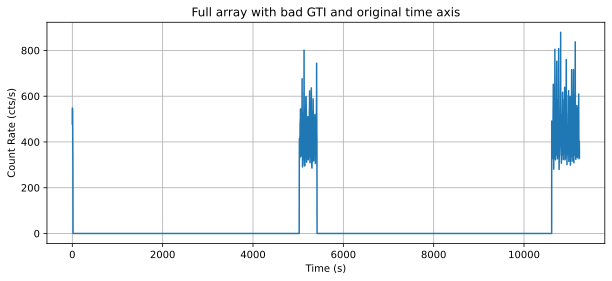

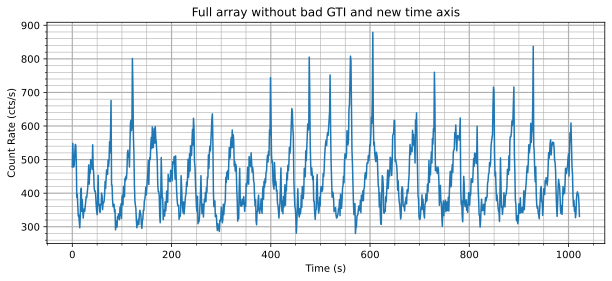

In [4]:
#Extract unmodified lightcurve from event file
lc_raw = events.to_lc(dt=1)

#Remove all zeros from the lightcurve that come from bad GTI and define a new time array independent of the observation start
full_array_zeros = lc_raw.counts
full_array = full_array_zeros[np.nonzero(full_array_zeros)]
t_full_array = np.linspace(0, len(full_array), len(full_array))

full_array_duration = len(full_array)
print("Full array duration:", full_array_duration, "s")
print("Duration of original observation incuding bad GTIs:", len(lc_raw.counts), "s")


#Plot original light curve
plt.figure(figsize=(10, 4))
plt.title("Full array with bad GTI and original time axis")
plt.plot(np.linspace(0, len(lc_raw.counts), len(lc_raw.counts)), lc_raw.counts)
plt.grid()
plt.xlabel('Time (s)')
plt.ylabel('Count Rate (cts/s)')

#Plot new full array
plt.figure(figsize=(10,4))
plt.title("Full array without bad GTI and new time axis")
plt.plot(t_full_array, full_array)
plt.minorticks_on()
plt.grid(which='major', linewidth=1.2)
plt.grid(which='minor', linewidth=0.6)
plt.xlabel('Time (s)')
plt.ylabel('Count Rate (cts/s)')

Definition of the function that finds the starting points of the cycles

In [5]:
def find_repetition_starts(small_array, large_array, distance, prominence=0.8):
    """
    Finds the starting indices in 'large_array' where a pattern similar to 'small_array' repeats.
    Uses peak detection on the correlation function instead of a fixed threshold.

    Parameters
    ----------
    small_array : np.ndarray
        Reference light curve segment to match.
    large_array : np.ndarray
        Larger light curve to search in.
    distance : int, optional
        Minimum separation (in samples) between detected peaks.
        This helps prevent detecting multiple close peaks within one repetition.
    prominence : float, optional
        Minimum prominence of a peak in the correlation curve, controlling sensitivity.

    Returns
    -------
    starting_points : list of int
        Estimated starting indices of pattern repetitions in the large array.
    correlation : np.ndarray
        The full correlation curve (useful for diagnostic plotting).
    """

    small_len = len(small_array)
    large_len = len(large_array)
    correlation = np.zeros(large_len - small_len + 1)

    # Compute sliding correlation coefficient
    for i in range(large_len - small_len + 1):
        segment = large_array[i:i + small_len]
        corr_value = np.corrcoef(segment, small_array)[0, 1]
        correlation[i] = corr_value

    # --- Find local maxima (peaks) in the correlation function ---
    # 'distance' ensures we only pick one peak per repetition
    # 'prominence' filters out small fluctuations
    peaks, _ = find_peaks(correlation, distance=distance, prominence=prominence)

    # Return peak indices and correlation for inspection
    return peaks.tolist(), correlation

First run of `find_repetition_starts` of a small segment over a larger segment of the light curve

Amount of detected repetition centers: 16 out of a theoretical maximum of 12
Mean of Peak Correlation Values: 0.8575566154864949
period time of averaged lightcurve: 40


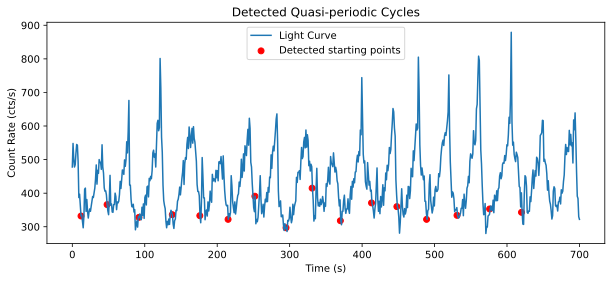

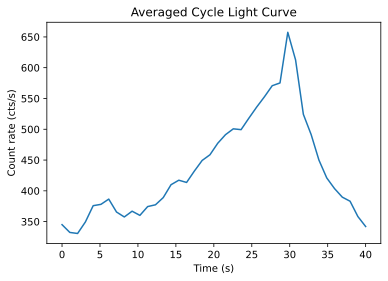

In [6]:
#==================================================================================================
#STEP 1: Define both intervals and the minimal distance between repetitions
#==================================================================================================

#Chose the two segments according to you estimation when looking at the full light curve above. 
#The smaller segment should roughly be of the period of one cycle and the larger one should span 
#multiple cycle periods
#Tip: rather overestimate than underestimate the period time here
lc_small1_start = 92
lc_small1_end = 150

lc_large1_start = 0
lc_large1_end = 700

#Define a minimal distance between starting points
min_distance_between_repetition1 = 35


small1_array = full_array[lc_small1_start:lc_small1_end]
large1_array = full_array[lc_large1_start:lc_large1_end]

#==================================================================================================
#STEP 2: Detect repetitions
#==================================================================================================
#Run find_repetition_starts for defined segments
starting_points1, correlation1 = find_repetition_starts(small1_array, large1_array, 
                                                        min_distance_between_repetition1)
print("Amount of detected repetition centers:", len(starting_points1), "out of a theoretical maximum of", 
      int(len(large1_array) / len(small1_array)))

#Compute the mean peak value of the correlation function for quality comparison 
#of the averaged lightcurve(s)
peak_values1 = list(correlation1[i] for i in starting_points1)
print("Mean of Peak Correlation Values:", np.mean(peak_values1))

#Compute mean cycle length
mean_len1 = int(np.mean(np.diff(starting_points1)))
print("period time of averaged lightcurve:", mean_len1)

# Plot the large light curve and mark detected peaks
plt.figure(figsize=(10,4))
plt.plot(np.linspace(0, len(large1_array), len(large1_array)), large1_array, label='Light Curve')
plt.scatter(starting_points1, large1_array[starting_points1], color='r', label='Detected starting points')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Count Rate (cts/s)')
plt.title('Detected Quasi-periodic Cycles')
plt.show()


#==================================================================================================
#STEP 2: Extract and average repeating lightcurves
#==================================================================================================
#Extract new lightcurves based on detected times
new_lightcurves1 = []
for t in starting_points1:
    lc = large1_array[t:t + mean_len1]
    new_lightcurves1.append(lc)

#Average all cycles to obtain mean shape
averaged_lightcurve1 = np.mean(new_lightcurves1, axis=0)
t1 = np.linspace(0, len(averaged_lightcurve1), len(averaged_lightcurve1))

#Plot averaged lightcurve
plt.figure(figsize=(6,4))
plt.plot(t1, averaged_lightcurve1)
plt.xlabel('Time (s)')
plt.ylabel('Count rate (cts/s)')
plt.title('Averaged Cycle Light Curve')
plt.show()

Repeat this process using the just now obtained average cycle as the small segment and the whole observation as the large one

Amount of detected repetition centers: 25 out of a theoretical maximum of 25
Period time of averaged lightcurve: 40 +/- 3
Mean of Peak Correlation Values: 0.9093114499944304
Null hypothesis probability: 1.0
Ignored timeframes: 22 s, which is 2.1526418786692716 % of the whole observation


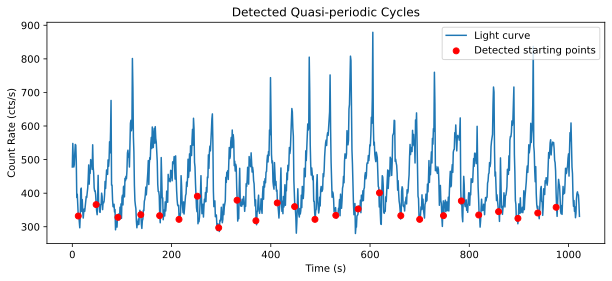

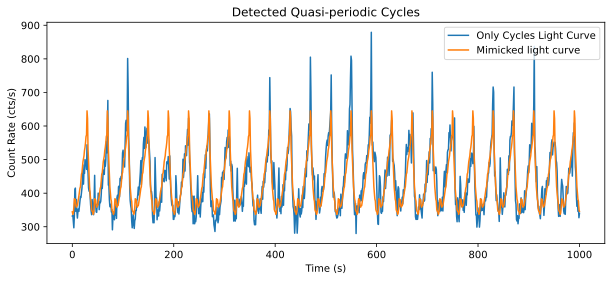

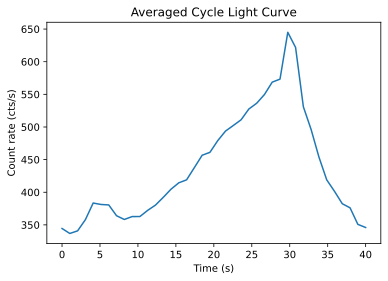

In [7]:
#==================================================================================================
# Step 4: Repeat the detection on the averaged pattern until it almost converged (depending on how fine-structured the quasi-periodicity is)
#==================================================================================================

lc_large2_start = 0
lc_large2_end = len(full_array)

min_distance_between_repetition2 = 35

small2_array = averaged_lightcurve1
large2_array = full_array[lc_large2_start:lc_large2_end]


#Run find_repetition_starts for defined segments
starting_points2, correlation2 = find_repetition_starts(small2_array, large2_array, min_distance_between_repetition2)
print("Amount of detected repetition centers:", len(starting_points2), "out of a theoretical maximum of", int(len(large2_array) / len(small2_array)))

#Compute mean cycle length
mean_len2 = int(np.mean(np.diff(starting_points2)))
mean_std2 = int(np.std(np.diff(starting_points2)))
print("Period time of averaged lightcurve:", mean_len2, '+/-', mean_std2)

#Extract new light curves based on detected times
new_lightcurves2 = []
for t in starting_points2:
    lc = large2_array[t:t + mean_len2]
    new_lightcurves2.append(lc)

#Average all cycles to obtain mean shape
averaged_lightcurve2 = np.mean(new_lightcurves2, axis=0)
t2 = np.linspace(0, len(averaged_lightcurve2), len(averaged_lightcurve2))

#Compute the mean peak value of the correlation function for a quality check of the averaged light curve(s)
peak_values2 = list(correlation2[i] for i in starting_points2)
print("Mean of Peak Correlation Values:", np.mean(peak_values2))


#Create array that only consists of cycles, i.e. from all starting points on we take a segment of mean_len2 and append all those, ignoring everything in between
only_cycles2_array = list(chain.from_iterable(new_lightcurves2))

#Mimick the only_cycles2_array using the average lightcurve appended len(starting_points2) times
mimicked_only_cycles2_array = []
for i in range(len(starting_points2)):
    mimicked_only_cycles2_array.append(averaged_lightcurve2)

mimicked_only_cycles2 = list(chain.from_iterable(mimicked_only_cycles2_array))

stat, p_value = ttest_ind(only_cycles2_array, mimicked_only_cycles2, equal_var=False)
print("Null hypothesis probability:", p_value)

#This approach naturally ignores some time frames due to the variability of the cycle period. Estimate to percentage of data that is ignored:
print("Ignored timeframes:", len(large2_array) - len(mimicked_only_cycles2), "s, which is", 100 - 100 * len(mimicked_only_cycles2) / len(large2_array), "%", "of the whole observation")


# Plot the large light curve and mark detected peaks
plt.figure(figsize=(10,4))
plt.plot(np.linspace(0, len(large2_array), len(large2_array)), large2_array, label='Light curve', zorder=1)
plt.scatter(starting_points2, large2_array[starting_points2], color='r', label='Detected starting points', zorder=2)
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Count Rate (cts/s)')
plt.title('Detected Quasi-periodic Cycles')
plt.show()


#print(mimicked_only_cycles2)
plt.figure(figsize=(10,4))
plt.plot(np.linspace(0, len(only_cycles2_array), len(only_cycles2_array)), only_cycles2_array, label='Only Cycles Light Curve')
plt.plot(np.linspace(0, len(mimicked_only_cycles2), len(mimicked_only_cycles2)), mimicked_only_cycles2, label='Mimicked light curve')
#plt.plot(t_full_array, full_array)
#plt.scatter(starting_points2, large2_array[starting_points2], color='r', label='Detected cycles')
plt.legend()
#plt.xlim(1200, 1300)
plt.xlabel('Time (s)')
plt.ylabel('Count Rate (cts/s)')
plt.title('Detected Quasi-periodic Cycles')
plt.show()


#Plot averaged lightcurve
plt.figure(figsize=(6,4))
plt.plot(t2, averaged_lightcurve2)
plt.xlabel('Time (s)')
plt.ylabel('Count rate (cts/s)')
plt.title('Averaged Cycle Light Curve')
plt.show()


As the last step, we want to create GTI files using the information about the cycle that we have just obtained. But first, the time array has to be changed back to the original

In [10]:
#==================================================================================================
#FINAL STEP: write the results into gti files and apply them in heasoft to extract source and bkg spectra for each phase bin
#==================================================================================================

def find_zero_intervals(lst):
    intervals = []
    start = None
    for i, val in enumerate(lst):
        if val == 0:
            if start is None:
                start = i
        else:
            if start is not None:
                intervals.append((start, i - 1))
                start = None
    if start is not None:
        intervals.append((start, len(lst) - 1))

    return intervals

badGTIs = find_zero_intervals(lc_raw.counts)


def shift_indices(strtpnts, GTIs):
    GTIs = sorted(GTIs, key=lambda x: x[0])

    new_indices = []
    for idx in strtpnts:
        shift = 0
        for a, b in GTIs:
            if a < idx + shift:
                shift += b - a + 2
        new_indices.append(idx + shift)
    return new_indices

#Re-insert the zero-count phases (bad GTI) that were there originally and shift the indices accordingly
interval_newtime = shift_indices(starting_points2, badGTIs)

#Chage the time array to the original time
interval = list(int(i + np.min(lc_raw.time)) for i in interval_newtime)


#Write txt file including the averaged cycle for plotting purposes in the later stages of the analysis
with open(f"../data/{ObsID}avgcycle.txt", "w") as f:
    writer = csv.writer(f, delimiter='\t')
    writer.writerows(zip(t2, averaged_lightcurve2))

#Output important values to a txt file so you can visit them later on without having to run the code again
with open(f"../data/{ObsID}PhaRes_values.txt", "w") as f:
    print("Full array duration:", full_array_duration, "s", file=f)
    print("Duration of original observation incuding bad GTIs:", len(lc_raw.counts), "s", file=f)
    print("Amount of detected repetition centers:", len(starting_points2), "out of a theoretical maximum of", int(len(large2_array) / len(small2_array)), file=f)
    print("Period time of averaged lightcurve:", mean_len2, file=f)
    print("Mean of Peak Correlation Values:", np.mean(peak_values2), file=f)
    print("Null hypothesis probability:", p_value, file=f)
    print("Ignored timeframes:", len(large2_array) - len(mimicked_only_cycles2), "s, which is", 100 - 100 * len(mimicked_only_cycles2) / len(large2_array), "%", file=f)
    print("First small interval:", lc_small1_start, lc_small1_end, "First large interval:", lc_large1_start, lc_large1_end, file=f)


#Define the number of bins our average lightcurve should be split into (should choose a reasonable value so that each bin has enough number of photons for spectra statistics)
n_phase_bin = 10

#Set the length of each phase bin; also possible for the overlap of cycles (if only the cycle shape is important): make the phase bins shorter by one standard deviation
t_phase = mean_len2 / n_phase_bin
#t_phase = (mean_len2 - mean_std2)/n_phase_bin


#Creation of n .fits files (GTI-files) and saving them in specified directory
#This has to be changed when working with a different telescope than NICER
for j in range(n_phase_bin):
    start_col = list(interval[i] + j * t_phase for i in range(len(interval)))
    stop_col = list(interval[i] + j * t_phase + t_phase for i in range(len(interval)))
    gti_table = Table([start_col, stop_col], names=('START', 'STOP'))
    hdu = fits.BinTableHDU(gti_table)
    primary_hdu = fits.PrimaryHDU()
    hdul = fits.HDUList([primary_hdu, hdu])
    hdul.writeto(f'../data/{ObsID}_GTI_phase{j+1:02}.fits', overwrite=True)

### Downsides to this approach to phase resolved analysis

- Ignores a little bit of data
- As this approach does not operate on the frequency domain, the start- and end-count-rate of the averaged cycle can differ, making the calculation of the period length unreliable sometimes; changing the initial small segment can help to minimize that effect
- The last bin(s) of an individual cycle can overlap the first bin(s) of the following, decreasing the quality of the spectral fit of the last bin(s); see following example

### Advantages to this approach

- Rather straightforward
- Transparent and variable
- Reliable cycle shape calculation

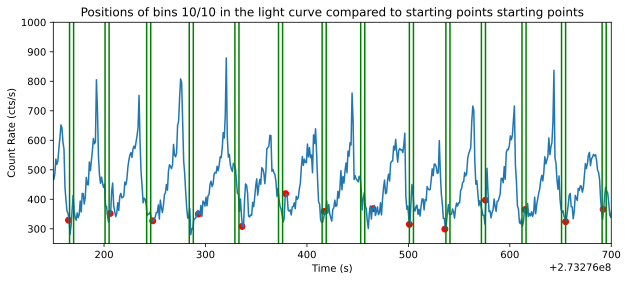

In [11]:
#Visualization of the overlap; this part is not necessary for the analysis

#Open the GTI-file for the 10th bin that was just created above
with fits.open(f'../data/{ObsID}_GTI_phase10.fits', memmap=False) as hdul:
    data = hdul[1].data
    START = data['START'].tolist()
    STOP = data['STOP'].tolist()


plt.figure(figsize=(10,4))
plt.plot(lc_raw.time, lc_raw.counts)
plt.vlines(START, 250, 1500, color="green")
plt.vlines(STOP, 250, 1500, color="green")
plt.xlim(273276150, 273276700)
plt.ylim(250, 1000)
plt.scatter(interval, lc_raw.counts[interval_newtime], color='red')
plt.title('Positions of bins 10/10 in the light curve compared to starting points starting points')
plt.xlabel('Time (s)')
plt.ylabel('Count Rate (cts/s)')

hdul.close()